In [8]:
import sys
sys.path.insert(0, "..")
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display
from src.pdm.config import load_config

sns.set_theme(style="whitegrid")
cfg = load_config("../config.yaml")

reports = "../outputs/reports/"
summary = json.load(open(os.path.join(reports, "summary.json")))
best_params = json.load(open(os.path.join(reports, "best_params.json")))
selected_features = json.load(open(os.path.join(reports, "selected_features.json")))
threshold_table = pd.read_csv(os.path.join(reports, "threshold_table.csv"))
component_metrics = pd.read_csv(os.path.join(reports, "component_metrics.csv"))

print(f"Horizon: {summary['horizon_hours']}h | AUC-PR: {summary['auc_pr']} | AUC-ROC: {summary['auc_roc']}")
print(f"Final features: {summary['n_features_final']}")
print(f"Best params: {json.dumps(best_params, indent=2)}")

Horizon: 12h | AUC-PR: 0.9944 | AUC-ROC: 0.9999
Final features: 20
Best params: {
  "n_estimators": 461,
  "max_depth": 8,
  "learning_rate": 0.10673448131341882,
  "subsample": 0.7426991038395819,
  "colsample_bytree": 0.6451644307227298
}


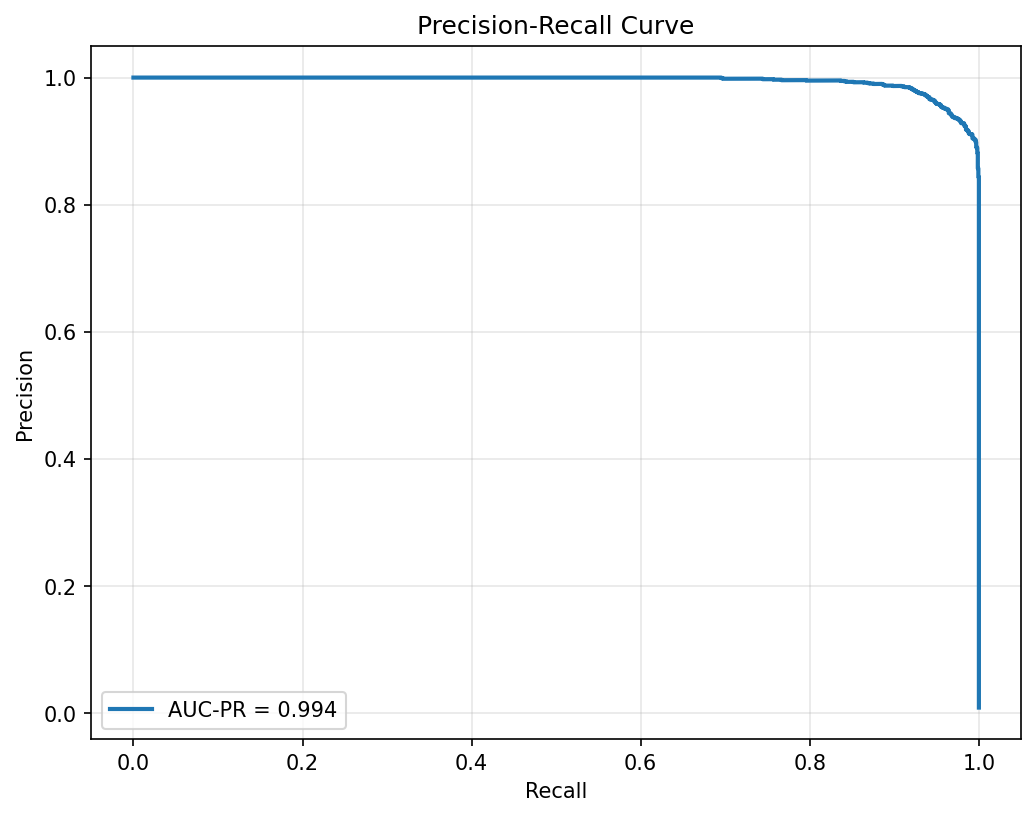

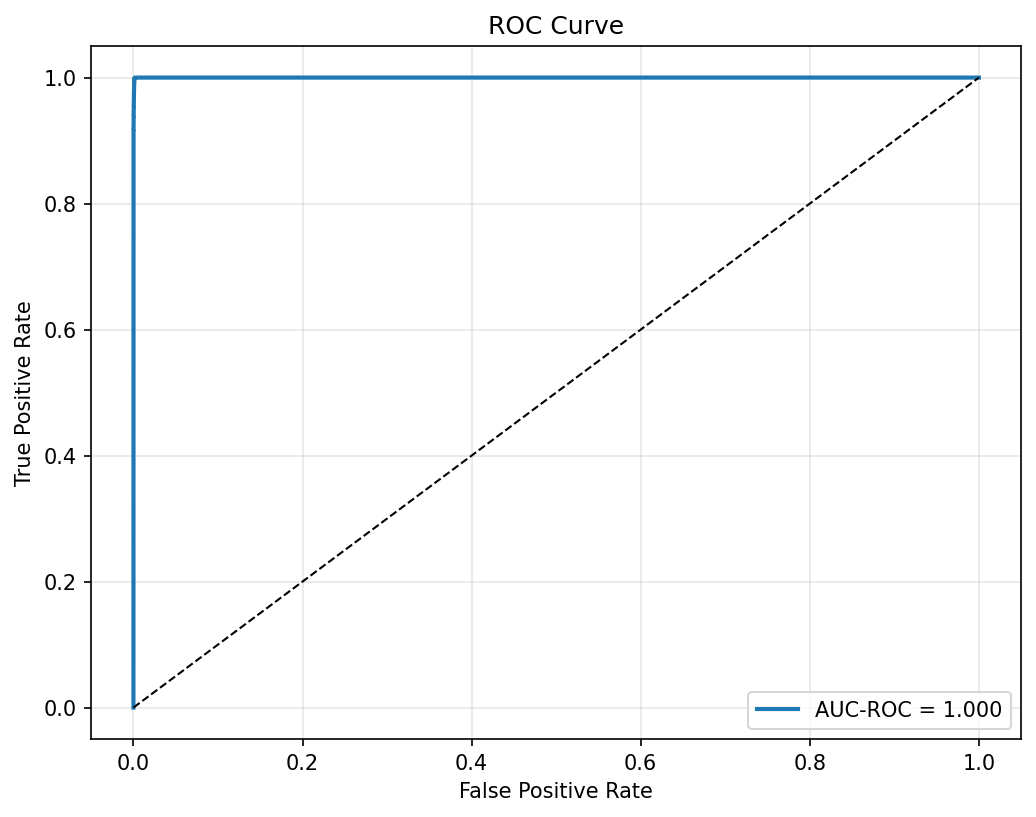

In [9]:
display(Image(filename=os.path.join(reports, "pr_curve.png")))
display(Image(filename=os.path.join(reports, "roc_curve.png")))

Threshold Sensitivity Table:
 threshold  precision   recall       f1
      0.10   0.867403 0.998728 0.928445
      0.15   0.879059 0.998728 0.935080
      0.20   0.883944 0.998092 0.937556
      0.25   0.891354 0.996819 0.941141
      0.30   0.896453 0.996819 0.943976
      0.35   0.901036 0.996183 0.946224
      0.40   0.903991 0.994275 0.946986
      0.45   0.906977 0.992366 0.947752
      0.50   0.910099 0.991730 0.949163
      0.55   0.910955 0.989186 0.948460
      0.60   0.916175 0.987277 0.950398
      0.65   0.918149 0.984733 0.950276
      0.70   0.922527 0.984733 0.952615
      0.75   0.928443 0.982188 0.954560
      0.80   0.931557 0.978372 0.954390
      0.85   0.937846 0.969466 0.953394


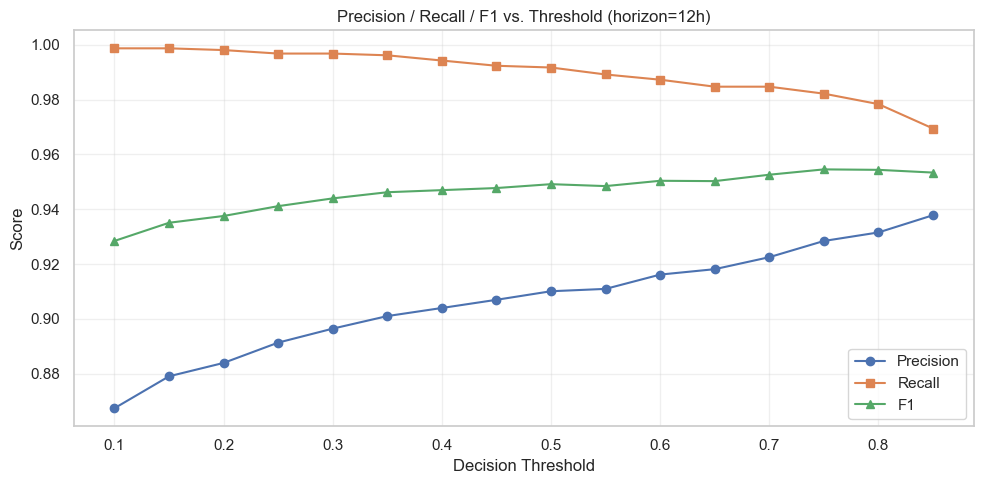

In [10]:
print("Threshold Sensitivity Table:")
print(threshold_table.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(threshold_table["threshold"], threshold_table["precision"], "o-", label="Precision")
ax.plot(threshold_table["threshold"], threshold_table["recall"], "s-", label="Recall")
ax.plot(threshold_table["threshold"], threshold_table["f1"], "^-", label="F1")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title(f"Precision / Recall / F1 vs. Threshold (horizon={summary['horizon_hours']}h)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Per-Component Metrics:
component  precision   recall       f1  n_failures
    comp4   0.220665 0.984375 0.360515         384
    comp1   0.237595 0.997549 0.383781         408
    comp2   0.356684 0.998366 0.525591         612
    comp3   0.157618 0.978261 0.271493         276


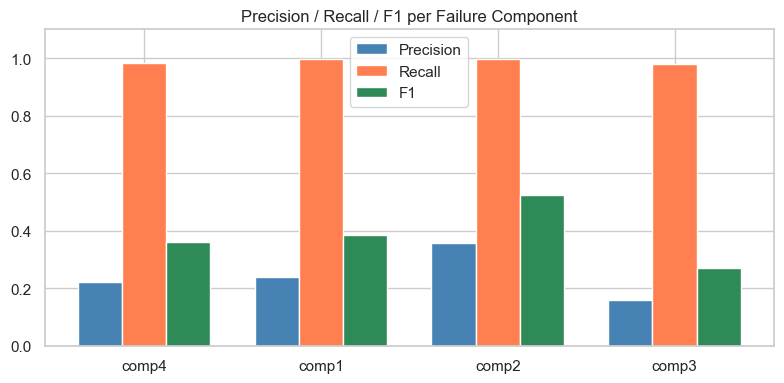

In [11]:
print("Per-Component Metrics:")
print(component_metrics.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(component_metrics))
width = 0.25
ax.bar([i - width for i in x], component_metrics["precision"], width, label="Precision", color="steelblue")
ax.bar(list(x), component_metrics["recall"], width, label="Recall", color="coral")
ax.bar([i + width for i in x], component_metrics["f1"], width, label="F1", color="seagreen")
ax.set_xticks(list(x))
ax.set_xticklabels(component_metrics["component"])
ax.set_ylim(0, 1.1)
ax.set_title("Precision / Recall / F1 per Failure Component")
ax.legend()
plt.tight_layout()
plt.show()

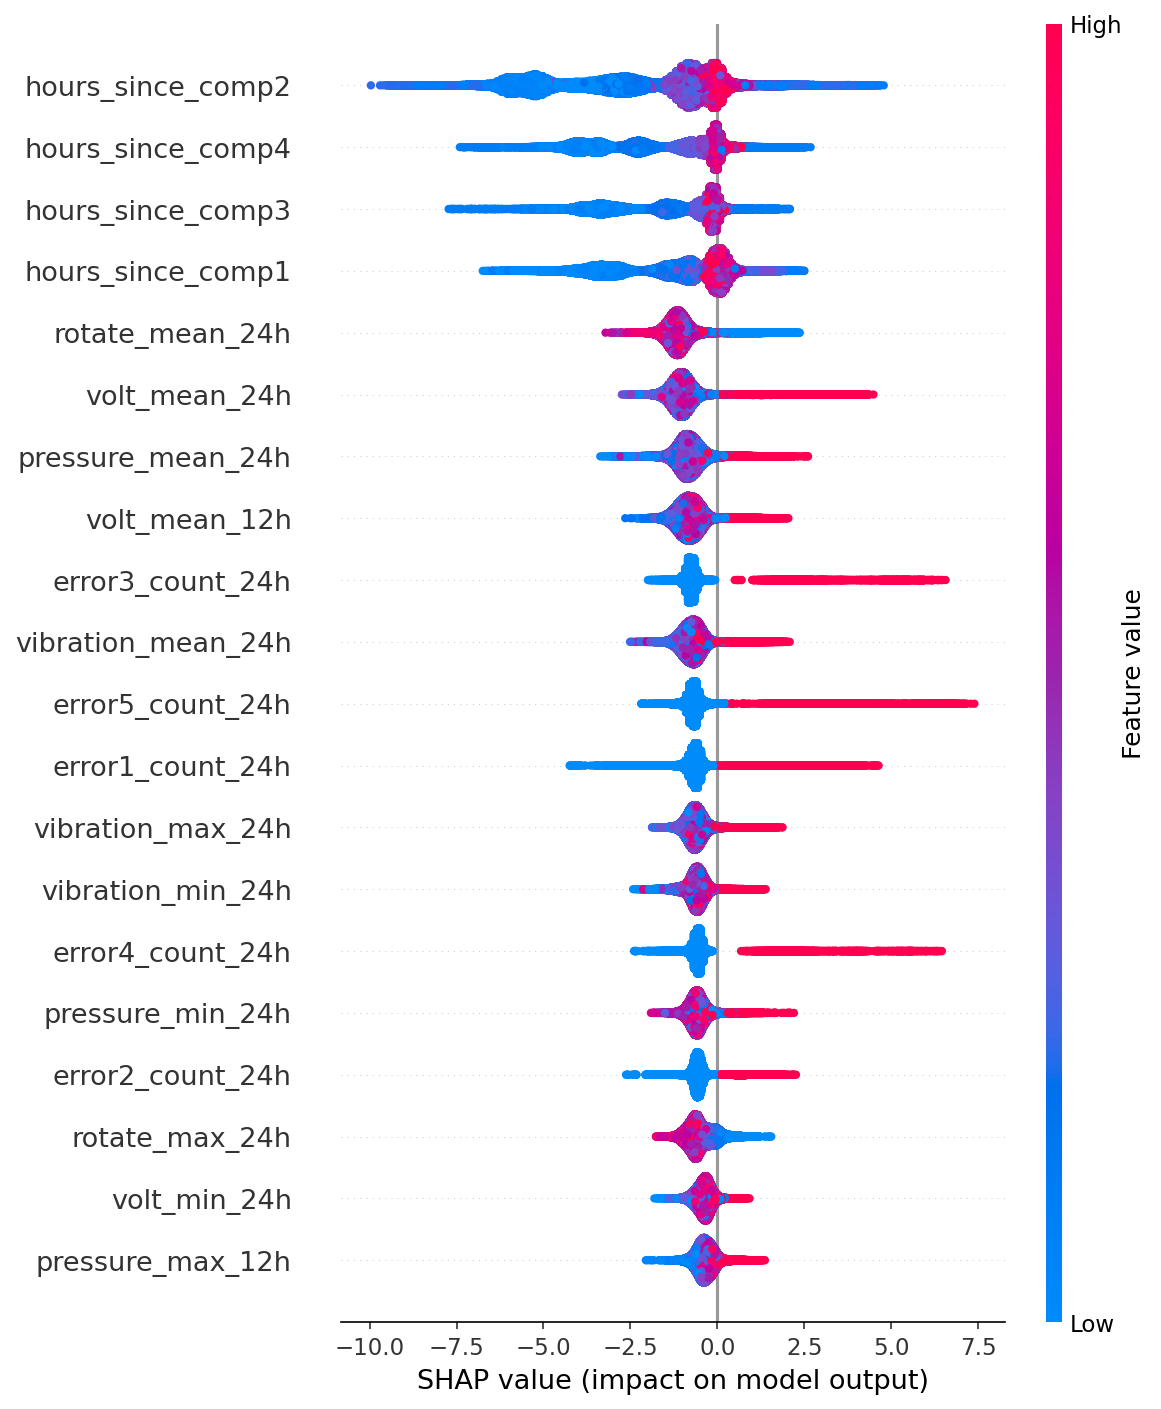


Selected features (by SHAP importance):
   1. hours_since_comp4
   2. hours_since_comp2
   3. error1_count_24h
   4. hours_since_comp1
   5. volt_mean_24h
   6. error4_count_24h
   7. error5_count_24h
   8. hours_since_comp3
   9. error3_count_24h
  10. vibration_mean_24h
  11. error2_count_24h
  12. rotate_mean_24h
  13. volt_mean_12h
  14. pressure_mean_24h
  15. rotate_max_24h
  16. pressure_min_24h
  17. vibration_max_24h
  18. volt_min_24h
  19. pressure_max_12h
  20. vibration_min_24h


In [12]:
display(Image(filename=os.path.join(reports, "shap_summary.png")))
print("\nSelected features (by SHAP importance):")
for i, f in enumerate(selected_features, 1):
    print(f"  {i:2d}. {f}")

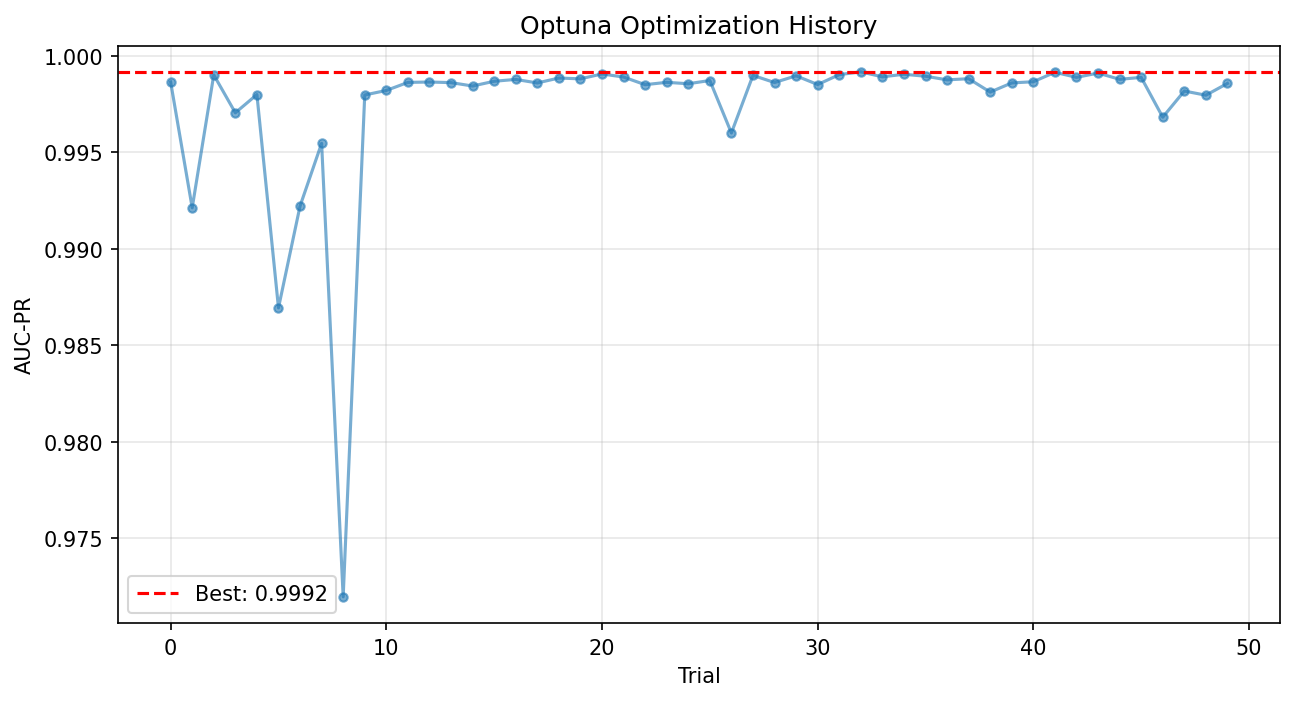

In [13]:
display(Image(filename=os.path.join(reports, "optuna_history.png")))